Processing basic_proxy from /Users/avshah/P_llm_auctions/llm-auction/experiment_logs/V10/ebay_proxy


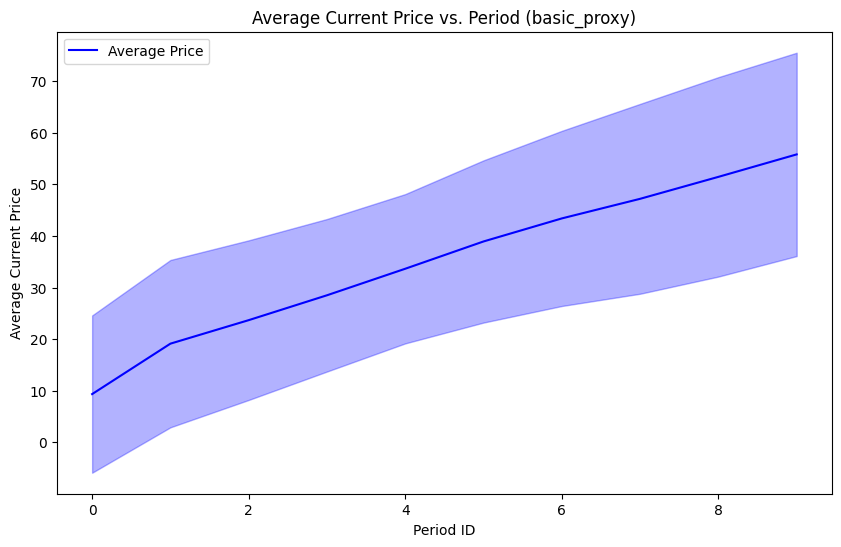

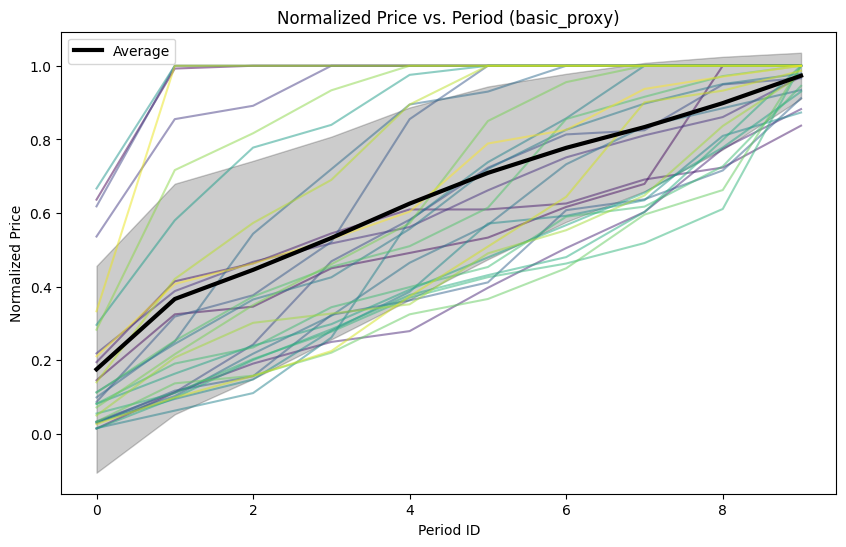

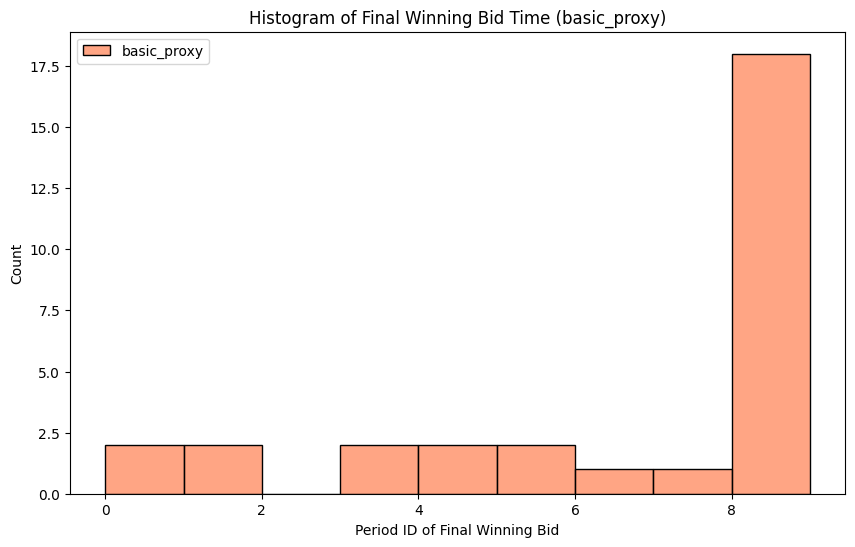

Processing closing_rule from /Users/avshah/P_llm_auctions/llm-auction/experiment_logs/V10/ebay_closing_rule


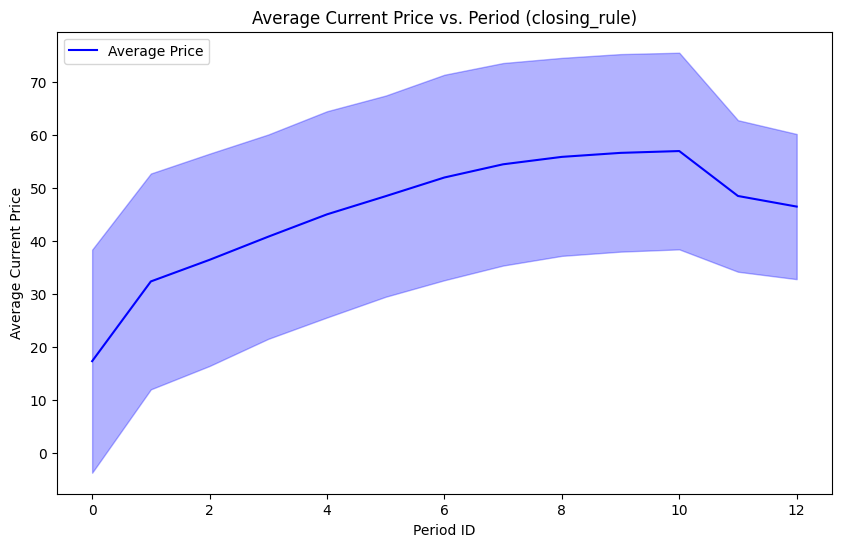

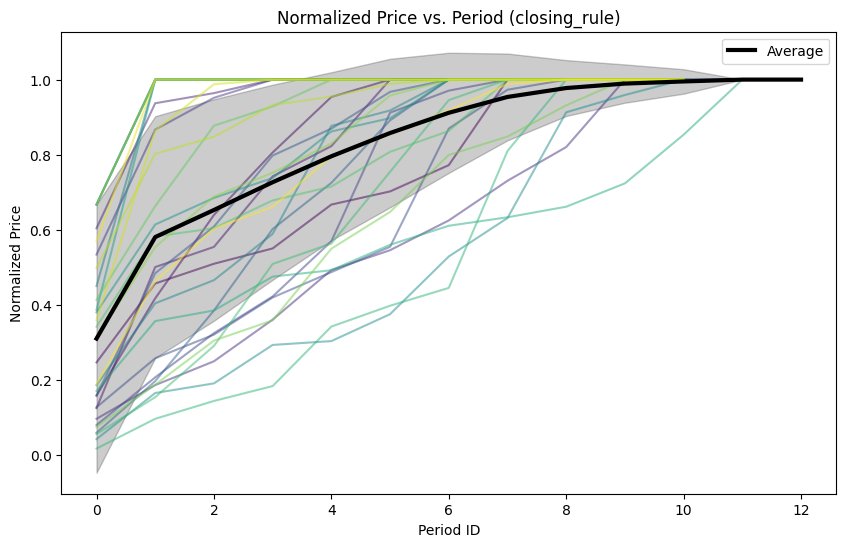

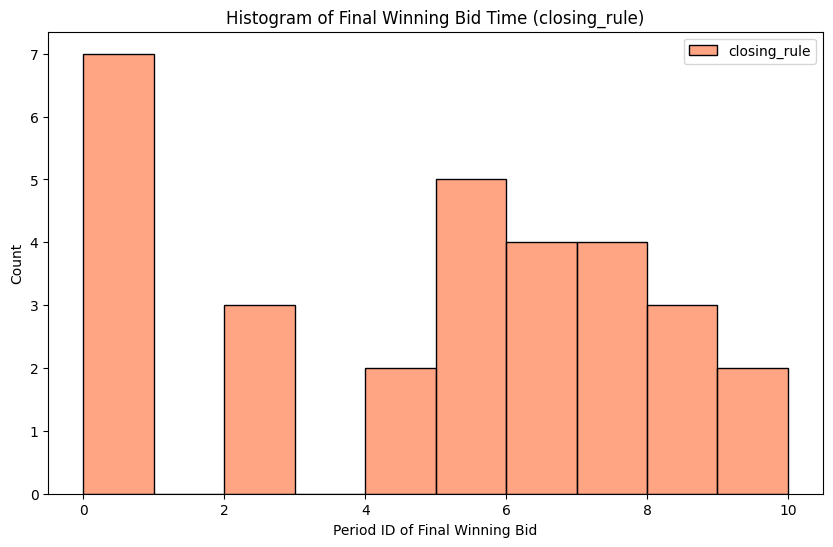

Processing hidden_reserve_40 from /Users/avshah/P_llm_auctions/llm-auction/experiment_logs/V10/ebay_proxy_with_hidden_reserve_40


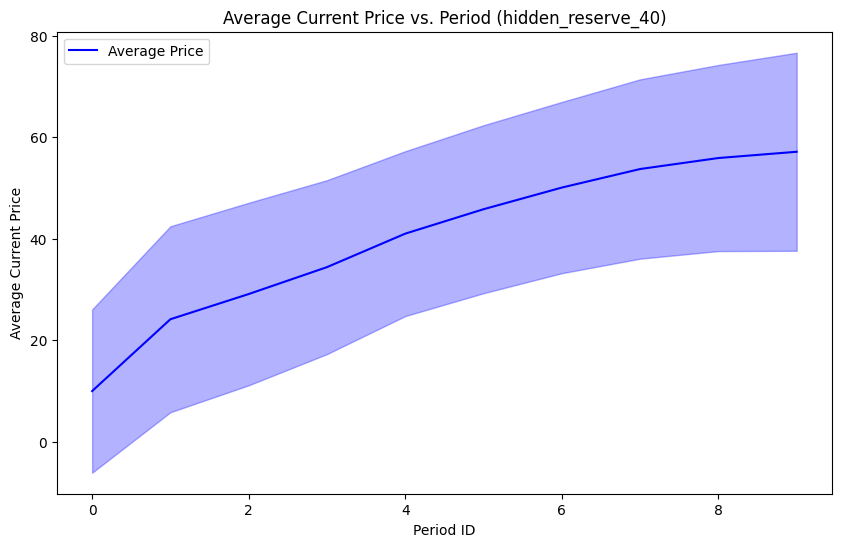

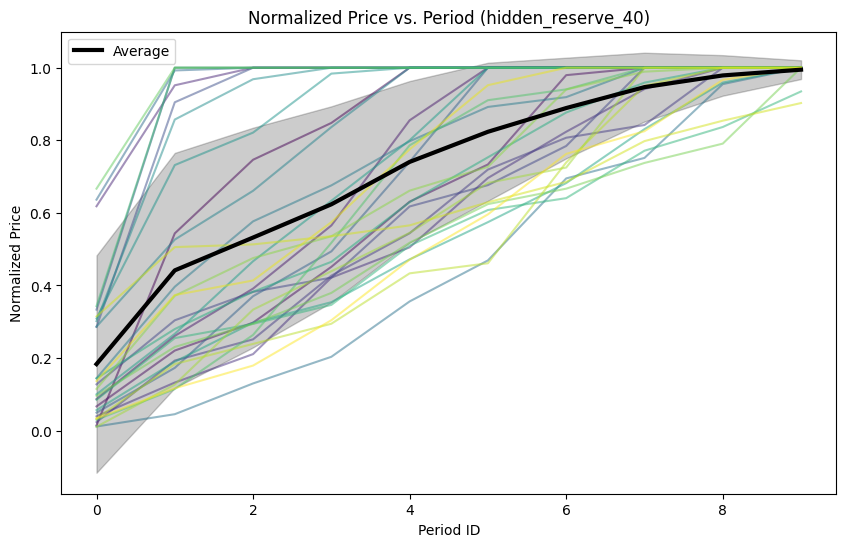

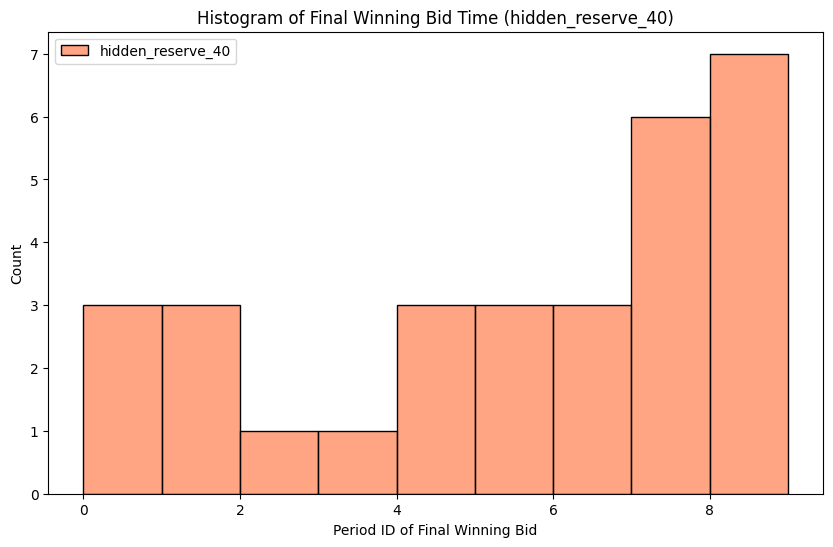

Processing hidden_reserve_50 from /Users/avshah/P_llm_auctions/llm-auction/experiment_logs/V10/ebay_proxy_with_hidden_reserve_50


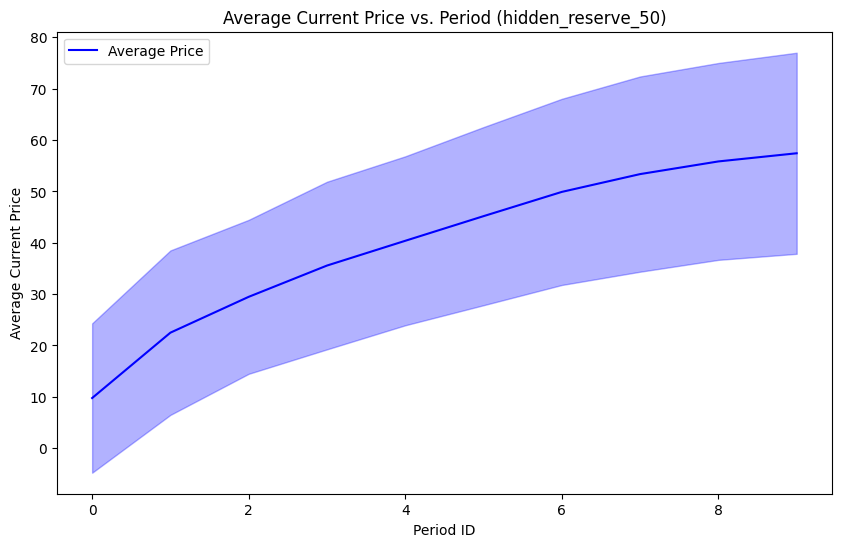

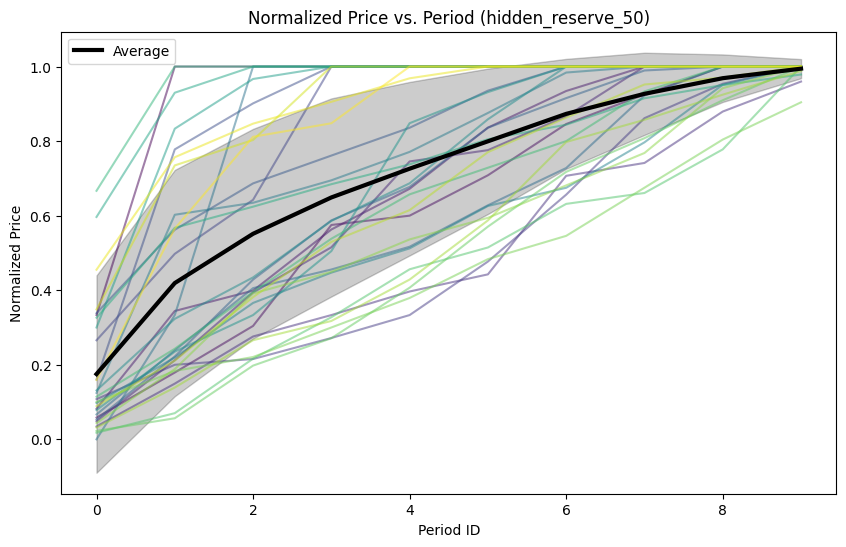

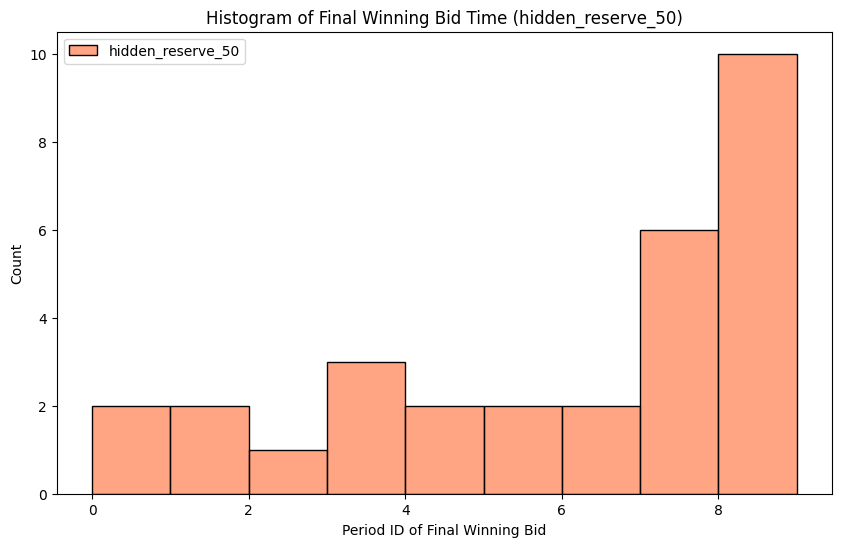

Processing hidden_reserve_60 from /Users/avshah/P_llm_auctions/llm-auction/experiment_logs/V10/ebay_proxy_with_hidden_reserve_60


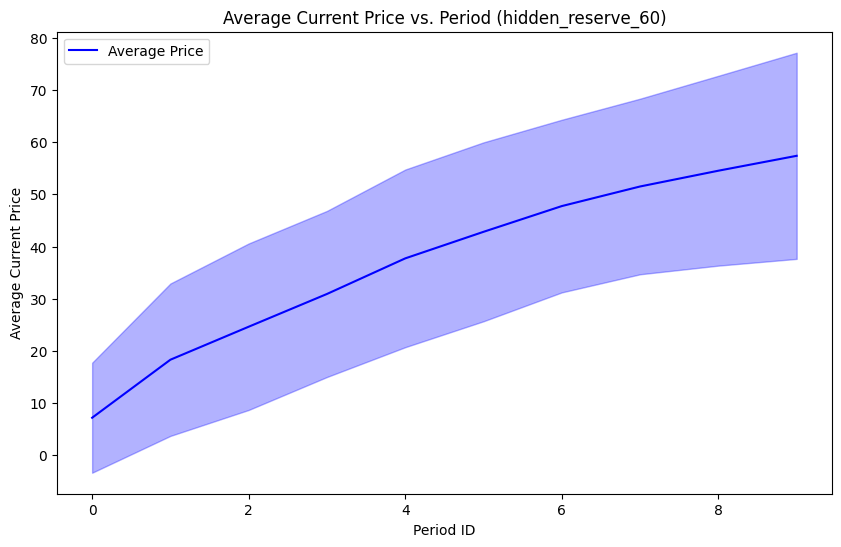

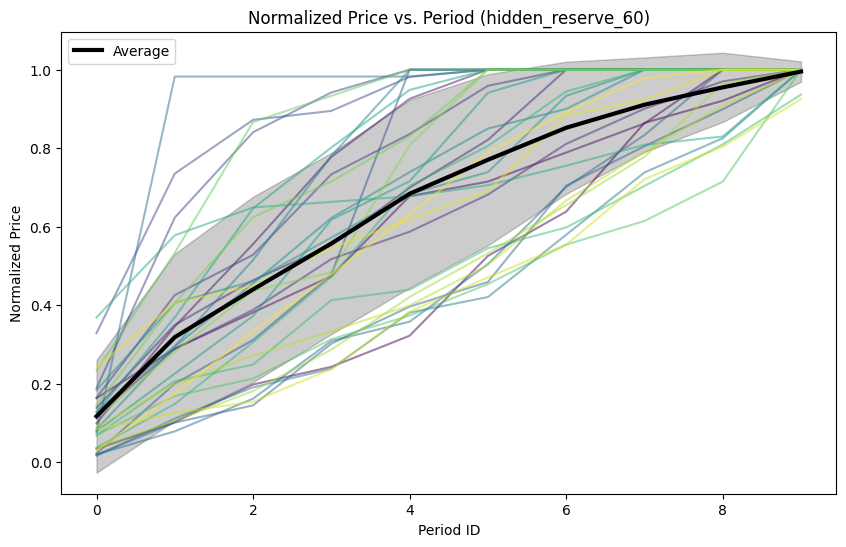

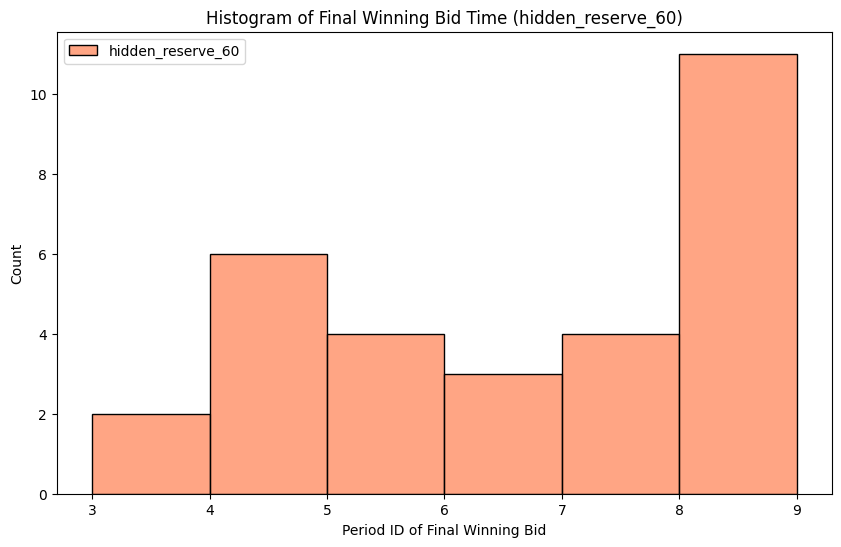

Processing closing_rule_hidden_40 from /Users/avshah/P_llm_auctions/llm-auction/experiment_logs/V10/ebay_closing_rule_with_hidden_reserve_40


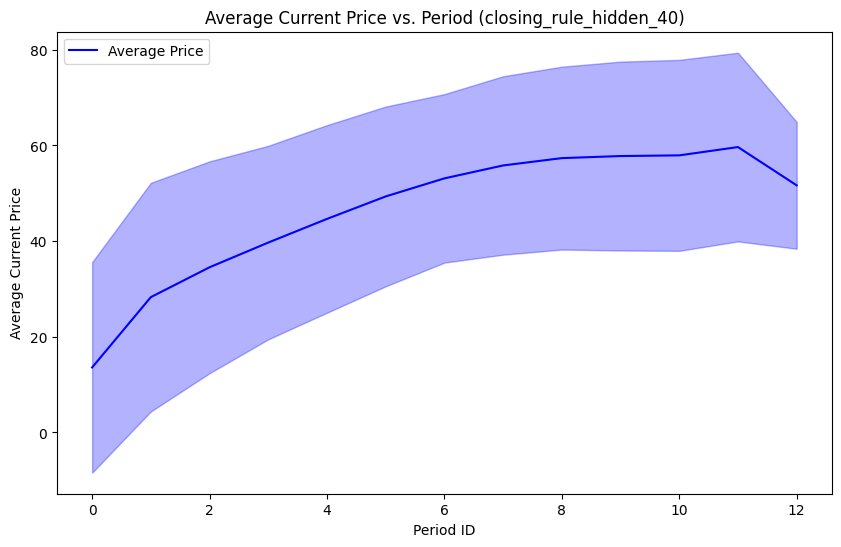

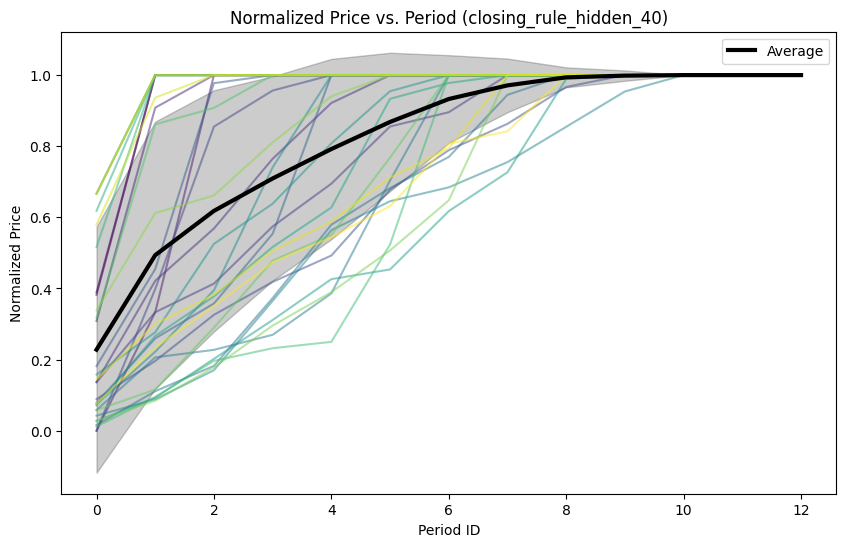

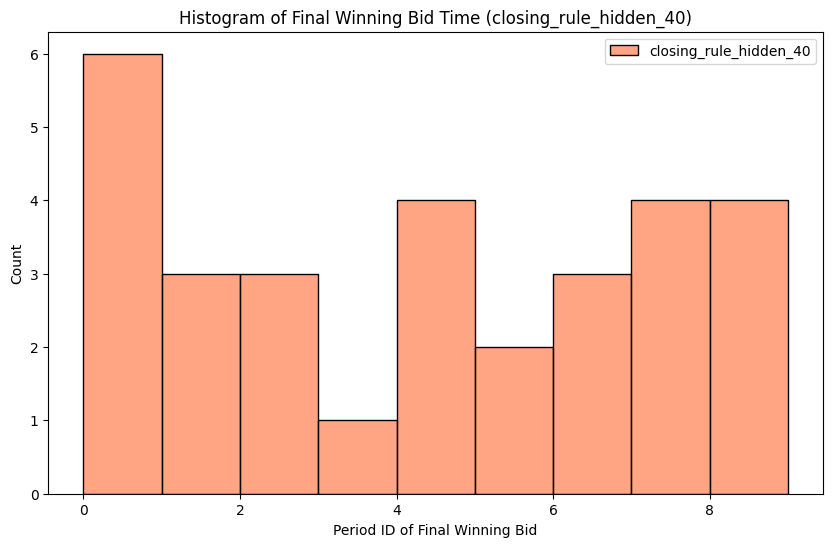

Processing closing_rule_hidden_50 from /Users/avshah/P_llm_auctions/llm-auction/experiment_logs/V10/ebay_closing_rule_with_hidden_reserve_50


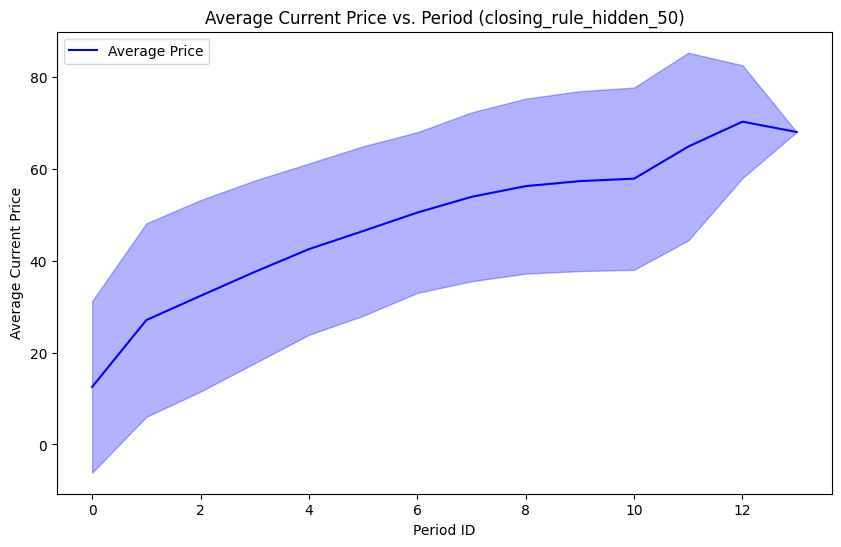

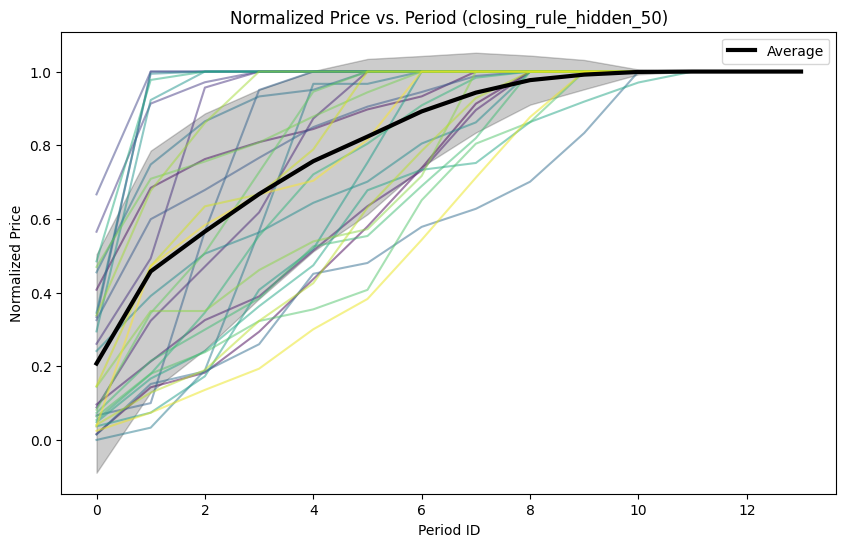

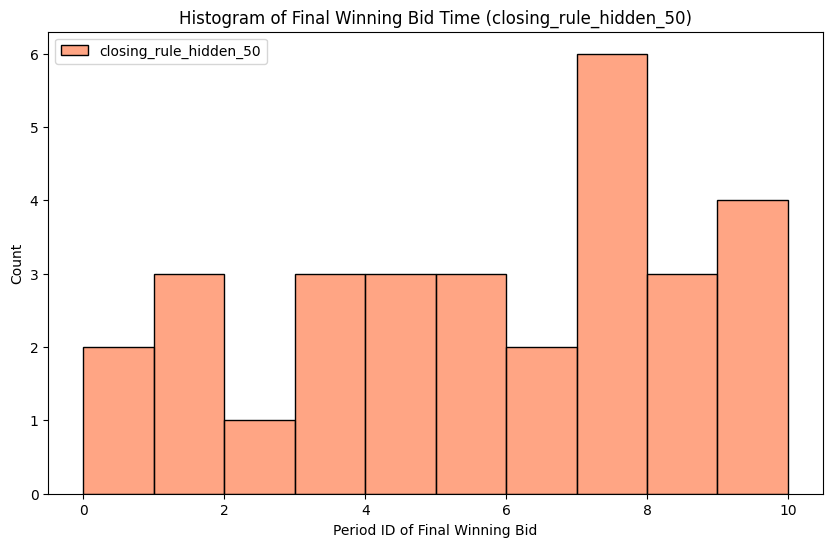

Processing closing_rule_hidden_60 from /Users/avshah/P_llm_auctions/llm-auction/experiment_logs/V10/ebay_closing_rule_with_hidden_reserve_60


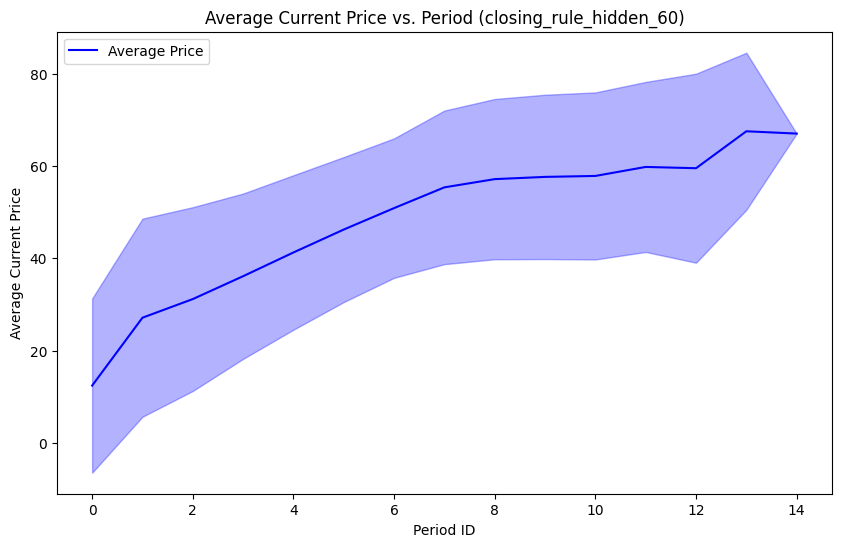

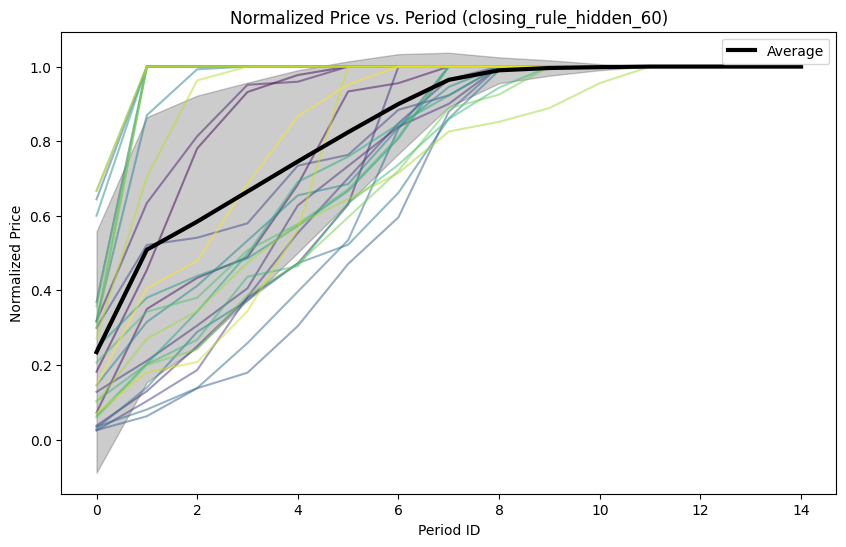

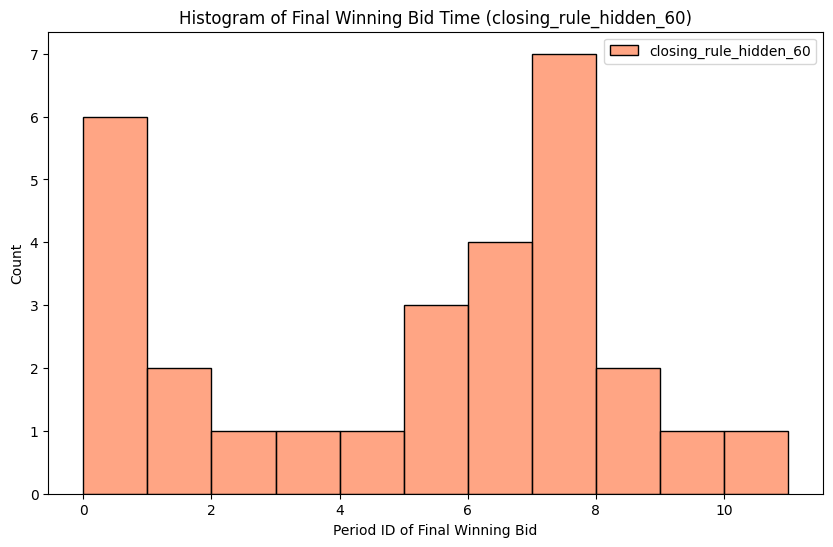

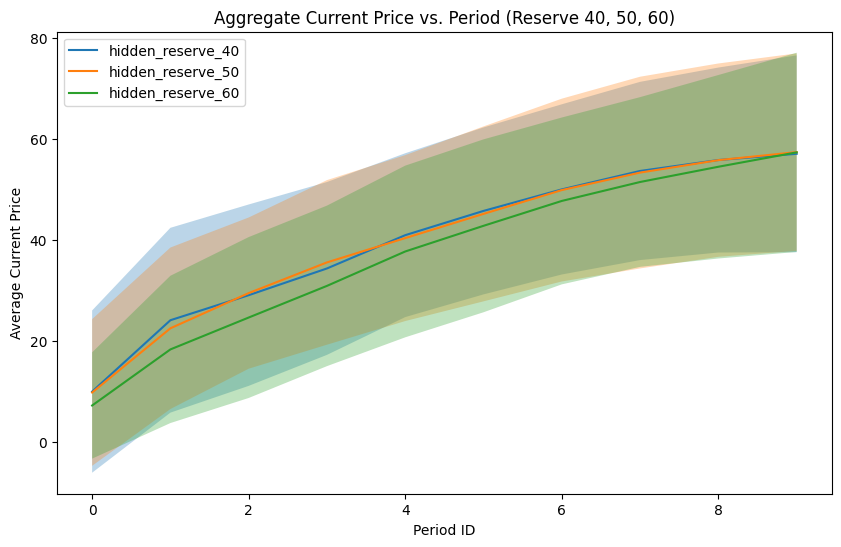

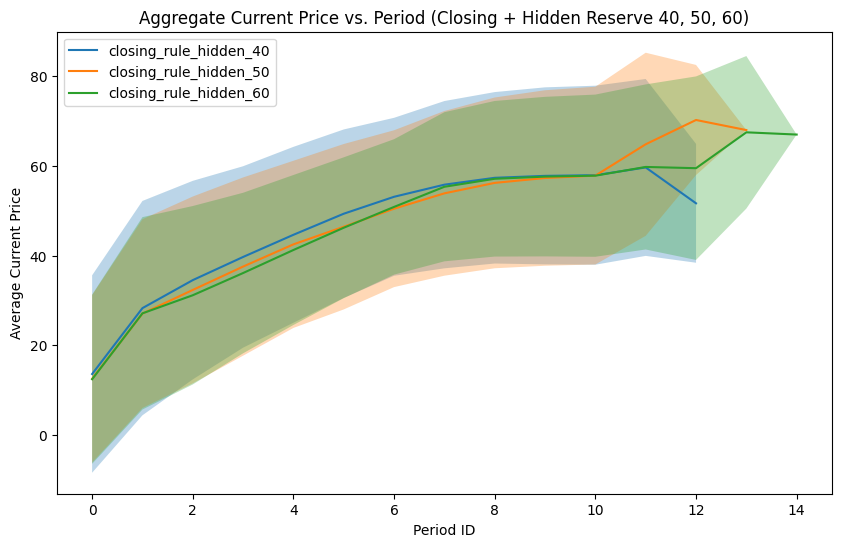

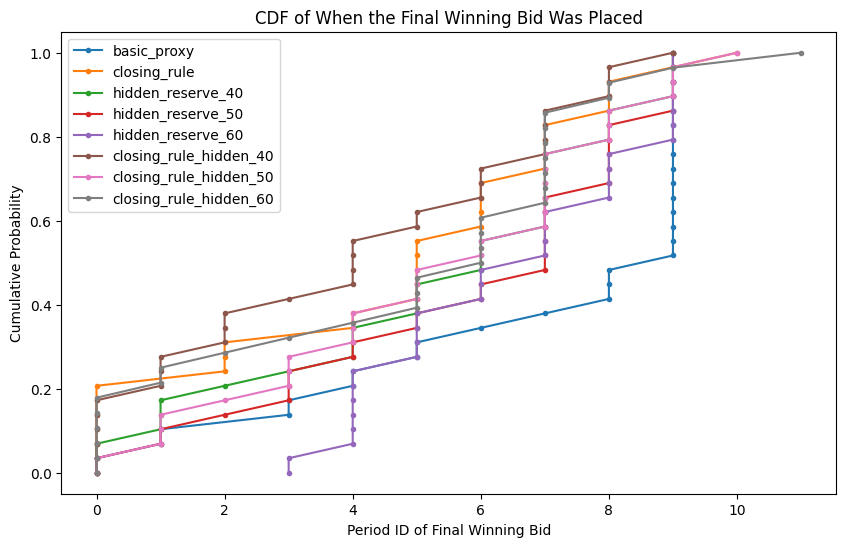

Summary Regression & Skewness Test Results:
            Experiment  Observations  Intercept Intercept p-value  Slope Slope p-value  R-squared  Residual Skew  Skew Test Statistic Skew Test p-value
           basic_proxy           600     24.677           3.3e-40  0.167       7.7e-09      0.054          0.499                4.792           1.7e-06
          closing_rule           675     29.769           2.8e-53  0.285       4.9e-21      0.123          0.026                0.283             0.777
     hidden_reserve_40           600     29.657           2.2e-51  0.205       8.4e-12      0.075          0.066                0.672             0.501
     hidden_reserve_50           900     31.561           5.0e-84  0.160       4.3e-11      0.047          0.045                0.554             0.579
     hidden_reserve_60           900     27.212           6.4e-67  0.192       2.0e-15      0.068          0.163                2.002             0.045
closing_rule_hidden_40           678     32.

In [13]:
import os
import glob
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import skew, skewtest, ttest_ind

warnings.filterwarnings('ignore', message='use_inf_as_na option is deprecated')

# -----------------------------------------------------------
# eBay Data Ingestion and Processing Functions
# -----------------------------------------------------------

def load_ebay_data(directory, ext=".csv"):
    """
    Loads all CSV files from the specified directory. Each file represents one run and is assigned an 'exp_num'.
    """
    csv_files = [f for f in os.listdir(directory) if f.endswith(ext)]
    dfs = []
    for i, file in enumerate(csv_files):
        df = pd.read_csv(os.path.join(directory, file))
        df['exp_num'] = i
        dfs.append(df)
    if dfs:
        return pd.concat(dfs, ignore_index=True)
    else:
        return pd.DataFrame()

def process_dataframe(df):
    """
    Processes the eBay auction DataFrame by grouping by exp_num and computing a normalized price.
    Normalized price = current_price / (final current_price in that run).
    """
    df = df.reset_index(drop=True)
    def calculate_normalized_price(group):
        final_price = group['current_price'].iloc[-1]
        group['normalized_price'] = group['current_price'] / final_price if final_price != 0 else 0
        return group
    df = df.groupby('exp_num').apply(calculate_normalized_price)
    return df

# -----------------------------------------------------------
# Individual Plotting Functions for eBay Data
# -----------------------------------------------------------

def plot_avg_price(df, label=""):
    """
    Plots the average current price vs. period, with standard deviation shading.
    """
    plt.figure(figsize=(10,6))
    avg_df = df.groupby("period_id")["current_price"].agg(["mean", "std"]).reset_index()
    
    sns.lineplot(data=avg_df, x="period_id", y="mean", label="Average Price", color="blue")
    plt.fill_between(avg_df["period_id"], avg_df["mean"] - avg_df["std"], avg_df["mean"] + avg_df["std"], alpha=0.3, color="blue")

    plt.xlabel("Period ID")
    plt.ylabel("Average Current Price")
    plt.title(f"Average Current Price vs. Period ({label})")
    plt.legend()
    plt.show()


def plot_price_vs_time(df, label=""):
    """
    Plots normalized price vs. period. Shows individual runs (with transparency) plus an average line with error bars.
    """
    plt.figure(figsize=(10,6))
    sns.lineplot(data=df, x='period_id', y='normalized_price', hue='exp_num', legend=False, alpha=0.5, palette="viridis", errorbar=None)
    sns.lineplot(data=df, x='period_id', y='normalized_price', estimator='mean', errorbar='sd', color='black', linewidth=3, label='Average')
    plt.xlabel("Period ID")
    plt.ylabel("Normalized Price")
    plt.title(f"Normalized Price vs. Period ({label})")
    plt.legend()
    plt.show()

# def plot_last_bid_histogram(df, label=""):
#     """
#     Plots a histogram of the period when the last bid was placed for each run.
#     """
#     experiment_ids = df['exp_num'].unique()
#     last_bid_periods = []
#     for exp_num in experiment_ids:
#         # Combine conditions in a single mask to avoid reindexing warnings.
#         bid_mask = (df['exp_num'] == exp_num) & (df['action'] == 'bid')
#         last_bid = df.loc[bid_mask, 'period_id'].max()
#         last_bid_periods.append(last_bid)
#     plt.figure(figsize=(10,6))
#     sns.histplot(last_bid_periods, binwidth=1, color='coral', alpha=0.7)
#     plt.xlabel("Period ID of Last Bid")
#     plt.ylabel("Count")
#     plt.title(f"Histogram of Last Bid Time ({label})")
#     plt.legend([label])
#     plt.show()

def plot_last_bid_histogram(df, label=""):
    """
    Plots a histogram of the period when the final winning price was first bid by the winning bidder.
    """
    experiment_ids = df['exp_num'].unique()
    final_winning_bid_periods = []

    for exp_num in experiment_ids:
        run_data = df[df['exp_num'] == exp_num].copy()
        run_data = run_data.sort_values(by="period_id")  # Ensure chronological order

        # Find the final winning price
        final_price = run_data["current_price"].iloc[-1]

        # Find the first period when this price was bid
        final_period = run_data[run_data["current_price"] == final_price]["period_id"].min()

        if not np.isnan(final_period):  # Ensure valid values
            final_winning_bid_periods.append(final_period)

    plt.figure(figsize=(10,6))
    sns.histplot(final_winning_bid_periods, binwidth=1, color='coral', alpha=0.7)
    plt.xlabel("Period ID of Final Winning Bid")
    plt.ylabel("Count")
    plt.title(f"Histogram of Final Winning Bid Time ({label})")
    plt.legend([label])
    plt.show()


def plot_aggregate_final_price(all_dfs, closing_keys, non_closing_keys):
    """
    Plots the final price distribution for closing rule vs. non-closing rule auctions.

    Args:
        all_dfs (dict): Dictionary of experiment DataFrames.
        closing_keys (list): List of closing rule experiment keys.
        non_closing_keys (list): List of non-closing rule experiment keys.
    """
    final_prices_closing = []
    final_prices_non_closing = []

    for exp_name in closing_keys:
        if exp_name in all_dfs:
            df = all_dfs[exp_name].copy()  # Ensure no modifications to the original DF
            df = df.reset_index()  # Fully reset index to remove potential ambiguity
            final_prices_closing.extend(
                df.groupby("exp_num", as_index=False)["current_price"].last()["current_price"].tolist()
            )

    for exp_name in non_closing_keys:
        if exp_name in all_dfs:
            df = all_dfs[exp_name].copy()
            df = df.reset_index()
            final_prices_non_closing.extend(
                df.groupby("exp_num", as_index=False)["current_price"].last()["current_price"].tolist()
            )

    # Create boxplot for visual comparison
    plt.figure(figsize=(8,6))
    sns.boxplot(data=[final_prices_closing, final_prices_non_closing], palette=["blue", "orange"])
    plt.xticks([0, 1], ["Closing Rule Auctions", "Non-Closing Rule Auctions"])
    plt.ylabel("Final Price")
    plt.title("Comparison of Final Prices: Closing Rule vs. Non-Closing Rule Auctions")
    plt.show()


# -----------------------------------------------------------
# Additional Plot: CDF of Last Bid Time (Aggregate)
# -----------------------------------------------------------
def plot_aggregated_avg_price(all_dfs, experiment_keys, title):
    """
    Plots the average current price vs. period for multiple experiments.
    Uses mean and standard deviation across runs.
    
    Args:
        all_dfs (dict): Dictionary of experiment DataFrames.
        experiment_keys (list): List of keys to include in the aggregate plot.
        title (str): Title of the plot.
    """
    plt.figure(figsize=(10,6))
    
    for exp_name in experiment_keys:
        if exp_name in all_dfs:
            df = all_dfs[exp_name]
            avg_df = df.groupby("period_id")["current_price"].agg(["mean", "std"]).reset_index()

            sns.lineplot(data=avg_df, x="period_id", y="mean", label=exp_name)
            plt.fill_between(avg_df["period_id"], avg_df["mean"] - avg_df["std"], avg_df["mean"] + avg_df["std"], alpha=0.3)

    plt.xlabel("Period ID")
    plt.ylabel("Average Current Price")
    plt.title(title)
    plt.legend()
    plt.show()

def plot_cdf_from_list(data_list, label=""):
    """
    Plots a CDF from a given list of numerical values.
    """
    sorted_data = np.sort(data_list)
    p = np.arange(len(sorted_data)) / (len(sorted_data) - 1)
    plt.plot(sorted_data, p, marker='.', linestyle='-', label=label)

# def aggregate_cdf_last_bid(all_dfs):
#     """
#     Aggregates last bid periods for each experiment and creates a combined CDF plot.
#     """
#     plt.figure(figsize=(10,6))
#     for exp_name, df in all_dfs.items():
#         experiment_ids = df['exp_num'].unique()
#         last_bid_periods = []
#         for exp_num in experiment_ids:
#             bid_mask = (df['exp_num'] == exp_num) & (df['action'] == 'bid')
#             last_bid = df.loc[bid_mask, 'period_id'].max()
#             last_bid_periods.append(last_bid)
#         if last_bid_periods:
#             plot_cdf_from_list(last_bid_periods, label=exp_name)
#     plt.xlabel("Period ID of Last Bid")
#     plt.ylabel("Cumulative Probability")
#     plt.title("CDF of Last Bid Time by Experiment")
#     plt.legend()
#     plt.show()

def aggregate_cdf_last_bid(all_dfs):
    """
    Aggregates the period when the final winning price was bid for each auction run
    and creates a combined CDF plot.
    """
    plt.figure(figsize=(10,6))

    for exp_name, df in all_dfs.items():
        experiment_ids = df['exp_num'].unique()
        final_winning_bid_periods = []

        for exp_num in experiment_ids:
            run_data = df[df['exp_num'] == exp_num].copy()
            run_data = run_data.sort_values(by="period_id")  # Ensure chronological order

            # Find the final winning price of this auction run
            final_price = run_data["current_price"].iloc[-1]

            # Find the FIRST period when this price was bid
            final_period = run_data[run_data["current_price"] == final_price]["period_id"].min()

            if not np.isnan(final_period):  # Ensure valid values
                final_winning_bid_periods.append(final_period)

        if final_winning_bid_periods:
            plot_cdf_from_list(final_winning_bid_periods, label=exp_name)

    plt.xlabel("Period ID of Final Winning Bid")
    plt.ylabel("Cumulative Probability")
    plt.title("CDF of When the Final Winning Bid Was Placed")
    plt.legend()
    plt.show()


# -----------------------------------------------------------
# Regression and Skewness Analysis for eBay Data
# -----------------------------------------------------------

def compute_regression_and_skew_tests(df):
    """
    Aggregates data from the eBay DataFrame (expects 'value' and 'current_price'),
    drops non-finite entries, fits a regression (current_price on value), and computes:
      - Intercept, Slope, R-squared,
      - Residual Skew and a formal skew test statistic and p-value.
    Also returns the intercept and slope p-values.
    """
    if 'value' not in df.columns or 'current_price' not in df.columns:
        return None
    X = df['value'].values
    y = df['current_price'].values

    # Drop non-finite entries.
    mask = np.isfinite(X) & np.isfinite(y)
    X = X[mask]
    y = y[mask]
    n_obs = len(y)
    if n_obs == 0:
        return None

    X_with_const = sm.add_constant(X)
    model = sm.OLS(y, X_with_const).fit()
    intercept = model.params[0]
    slope = model.params[1]
    intercept_p = model.pvalues[0]
    slope_p = model.pvalues[1]
    r_squared = model.rsquared

    residuals = y - model.predict(X_with_const)
    residual_skew = skew(residuals)
    skew_test_stat, skew_test_p = skewtest(residuals)

    return {
        "Observations": n_obs,
        "Intercept": intercept,
        "Intercept p-value": intercept_p,
        "Slope": slope,
        "Slope p-value": slope_p,
        "R-squared": r_squared,
        "Residual Skew": residual_skew,
        "Skew Test Statistic": skew_test_stat,
        "Skew Test p-value": skew_test_p
    }

def report_results_table(all_dfs):
    """
    Iterates through each experiment DataFrame, computes regression and skew tests,
    and returns a formatted summary table.
    """
    results = []
    for exp_name, df in all_dfs.items():
        stats_dict = compute_regression_and_skew_tests(df)
        if stats_dict is None:
            continue
        stats_dict["Experiment"] = exp_name
        results.append(stats_dict)
    table = pd.DataFrame(results)
    
    # Format columns for neatness.
    table["Observations"] = table["Observations"].astype(int)
    table["Intercept"] = table["Intercept"].round(3)
    table["Slope"] = table["Slope"].round(3)
    table["R-squared"] = table["R-squared"].round(3)
    table["Residual Skew"] = table["Residual Skew"].round(3)
    table["Skew Test Statistic"] = table["Skew Test Statistic"].round(3)
    
    def format_p(p):
        return f"{p:.1e}" if p < 0.001 else f"{p:.3f}"
    table["Intercept p-value"] = table["Intercept p-value"].apply(format_p)
    table["Slope p-value"] = table["Slope p-value"].apply(format_p)
    table["Skew Test p-value"] = table["Skew Test p-value"].apply(format_p)
    
    desired_order = ["Experiment", "Observations", "Intercept", "Intercept p-value",
                     "Slope", "Slope p-value", "R-squared", "Residual Skew",
                     "Skew Test Statistic", "Skew Test p-value"]
    table = table[desired_order]
    return table

# -----------------------------------------------------------
# Additional Analysis: Seller Revenue & Auction Duration
# -----------------------------------------------------------

def compute_seller_revenue(df):
    """
    Computes seller revenue for each run by taking the final current_price.
    """
    revenues = []
    for exp_num in df['exp_num'].unique():
        run_data = df[df['exp_num'] == exp_num]
        final_price = run_data['current_price'].iloc[-1]
        revenues.append(final_price)
    return revenues

def compute_auction_length(df):
    """
    Computes auction duration for each run by taking the last period_id where a bid was placed.
    """
    lengths = []
    for exp_num in df['exp_num'].unique():
        bid_mask = (df['exp_num'] == exp_num) & (df['action'] == 'bid')
        last_bid = df.loc[bid_mask, 'period_id'].max()
        lengths.append(last_bid)
    return lengths

# -----------------------------------------------------------
# Main Execution Function
# -----------------------------------------------------------

def main():
    base_dir = '/Users/avshah/P_llm_auctions/llm-auction/experiment_logs/V10/'
    # Define directories for each eBay experiment.
    experiments = {
        "basic_proxy": os.path.join(base_dir, "ebay_proxy"),
        "closing_rule": os.path.join(base_dir, "ebay_closing_rule"),
        "hidden_reserve_40": os.path.join(base_dir, "ebay_proxy_with_hidden_reserve_40"),
        "hidden_reserve_50": os.path.join(base_dir, "ebay_proxy_with_hidden_reserve_50"),
        "hidden_reserve_60": os.path.join(base_dir, "ebay_proxy_with_hidden_reserve_60"),
        "closing_rule_hidden_40": os.path.join(base_dir, "ebay_closing_rule_with_hidden_reserve_40"),
        "closing_rule_hidden_50": os.path.join(base_dir, "ebay_closing_rule_with_hidden_reserve_50"),
        "closing_rule_hidden_60": os.path.join(base_dir, "ebay_closing_rule_with_hidden_reserve_60")
    }
    
    all_dfs = {}
    # Process each experiment.
    for exp_name, directory in experiments.items():
        print(f"Processing {exp_name} from {directory}")
        df_raw = load_ebay_data(directory)
        if df_raw.empty:
            continue
        df = process_dataframe(df_raw)
        all_dfs[exp_name] = df
        
        # Generate individual plots.
        plot_avg_price(df, label=exp_name)
        plot_price_vs_time(df, label=exp_name)
        plot_last_bid_histogram(df, label=exp_name)
    
    # -----------------------------------------------------------
    # Aggregate Analysis
    # -----------------------------------------------------------
    # 1) Aggregate current price plots for different reserve price levels
    plot_aggregated_avg_price(
        all_dfs, 
        ["hidden_reserve_40", "hidden_reserve_50", "hidden_reserve_60"],
        "Aggregate Current Price vs. Period (Reserve 40, 50, 60)"
    )

    # 2) Aggregate current price plots for closing rule + hidden reserve variations
    plot_aggregated_avg_price(
        all_dfs, 
        ["closing_rule_hidden_40", "closing_rule_hidden_50", "closing_rule_hidden_60"],
        "Aggregate Current Price vs. Period (Closing + Hidden Reserve 40, 50, 60)"
    )
    
    # 3) CDF of last bid time.
    aggregate_cdf_last_bid(all_dfs)
    
    # 4) Summary Regression & Skewness Table.
    stats_table = report_results_table(all_dfs)
    print("Summary Regression & Skewness Test Results:")
    print(stats_table.to_string(index=False))

    
    # -----------------------------------------------------------
    # Hypothesis Testing: Seller Revenue & Auction Duration
    # -----------------------------------------------------------
    revenue_data = {}
    duration_data = {}
    for exp_name, df in all_dfs.items():
        revenue_data[exp_name] = compute_seller_revenue(df)
        duration_data[exp_name] = compute_auction_length(df)
    
    revenue_basic = revenue_data.get("basic_proxy", [])
    revenue_closing = revenue_data.get("closing_rule", [])
    revenue_hidden = revenue_data.get("hidden_reserve", [])
    revenue_closing_hidden = revenue_data.get("closing_rule_hidden_reserve_40", [])
    
    if revenue_basic and revenue_closing:
        t_stat, p_val = ttest_ind(revenue_closing, revenue_basic, equal_var=False)
        print(f"\nT-test for Seller Revenue: closing_rule vs basic_proxy: t={t_stat:.3f}, p={p_val:.3g}")
    if revenue_basic and revenue_hidden:
        t_stat, p_val = ttest_ind(revenue_hidden, revenue_basic, equal_var=False)
        print(f"T-test for Seller Revenue: hidden_reserve vs basic_proxy: t={t_stat:.3f}, p={p_val:.3g}")
    if revenue_basic and revenue_closing_hidden:
        t_stat, p_val = ttest_ind(revenue_closing_hidden, revenue_basic, equal_var=False)
        print(f"T-test for Seller Revenue: closing_rule_hidden_reserve vs basic_proxy: t={t_stat:.3f}, p={p_val:.3g}")
    
    duration_basic = duration_data.get("basic_proxy", [])
    duration_closing = duration_data.get("closing_rule", [])
    if duration_basic and duration_closing:
        t_stat, p_val = ttest_ind(duration_closing, duration_basic, equal_var=False)
        print(f"\nT-test for Auction Duration: closing_rule vs basic_proxy: t={t_stat:.3f}, p={p_val:.3g}")

if __name__ == "__main__":
    main()


# Extra plots

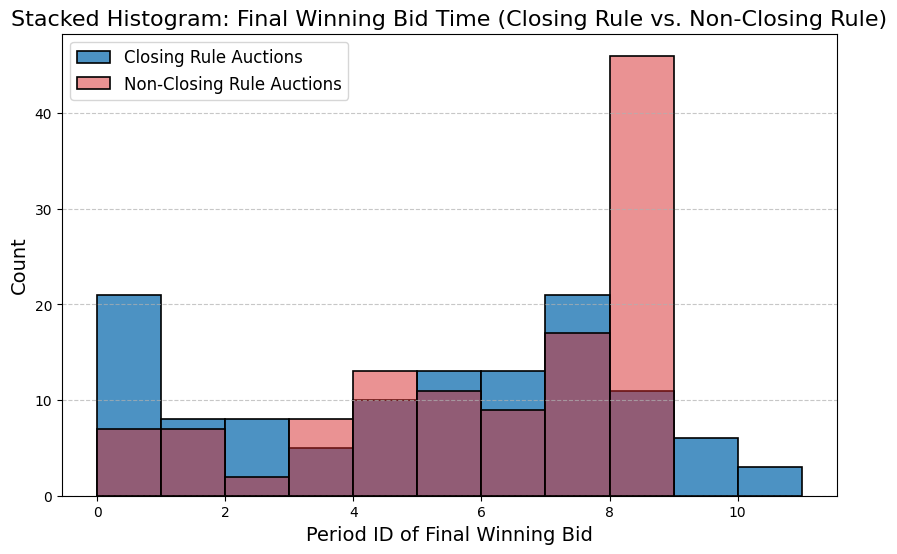

In [39]:
def plot_final_winning_bid_histogram_stacked(all_dfs, closing_keys, non_closing_keys):
    """
    Plots a stacked histogram of the period when the final winning price was first bid,
    separating closing rule auctions from non-closing rule auctions.
    
    Args:
        all_dfs (dict): Dictionary of experiment DataFrames.
        closing_keys (list): List of closing rule experiment keys.
        non_closing_keys (list): List of non-closing rule experiment keys.
    """
    closing_final_periods = []
    non_closing_final_periods = []

    for exp_name in closing_keys:
        if exp_name in all_dfs:
            df = all_dfs[exp_name].copy()
            experiment_final_periods = []
            for exp_num in df["exp_num"].unique():
                run_data = df[df["exp_num"] == exp_num].sort_values("period_id")
                final_price = run_data["current_price"].iloc[-1]
                final_period = run_data[run_data["current_price"] == final_price]["period_id"].min()
                if not np.isnan(final_period):
                    experiment_final_periods.append(final_period)
            closing_final_periods.extend(experiment_final_periods)

    for exp_name in non_closing_keys:
        if exp_name in all_dfs:
            df = all_dfs[exp_name].copy()
            experiment_final_periods = []
            for exp_num in df["exp_num"].unique():
                run_data = df[df["exp_num"] == exp_num].sort_values("period_id")
                final_price = run_data["current_price"].iloc[-1]
                final_period = run_data[run_data["current_price"] == final_price]["period_id"].min()
                if not np.isnan(final_period):
                    experiment_final_periods.append(final_period)
            non_closing_final_periods.extend(experiment_final_periods)

    # Plot stacked histogram with single colors per category
    plt.figure(figsize=(10,6))

    sns.histplot(closing_final_periods, binwidth=1, color="#1f77b4", alpha=0.8, edgecolor="black", linewidth=1.2, label="Closing Rule Auctions", multiple="stack")
    
    sns.histplot(non_closing_final_periods, binwidth=1, color="#d62728", alpha=0.5, edgecolor="black", linewidth=1.2, label="Non-Closing Rule Auctions", multiple="stack")

    plt.xlabel("Period ID of Final Winning Bid", fontsize=14)
    plt.ylabel("Count", fontsize=14)
    plt.title("Stacked Histogram: Final Winning Bid Time (Closing Rule vs. Non-Closing Rule)", fontsize=16)
    plt.legend(fontsize=12, loc="upper left", frameon=True)

    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

plot_final_winning_bid_histogram_stacked(
    all_dfs,
    closing_keys=["closing_rule", "closing_rule_hidden_40", "closing_rule_hidden_50", "closing_rule_hidden_60"],
    non_closing_keys=["basic_proxy", "hidden_reserve_40", "hidden_reserve_50", "hidden_reserve_60"]
)


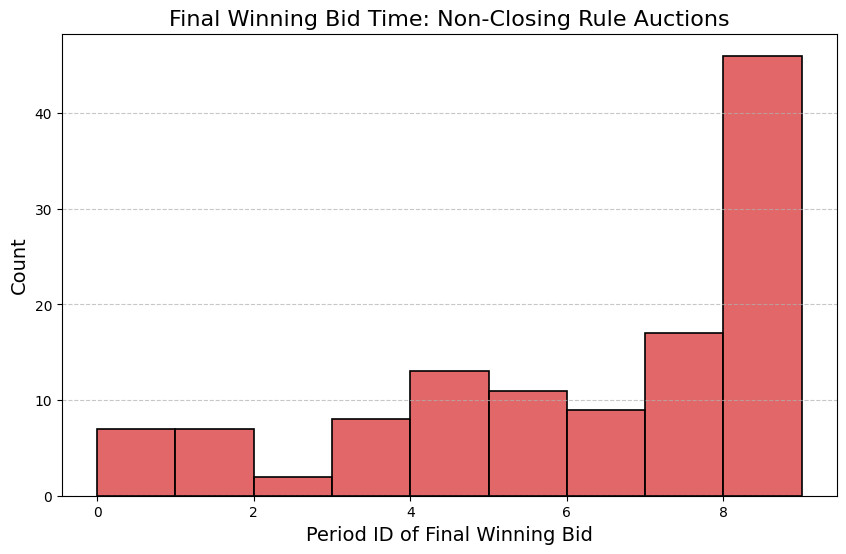

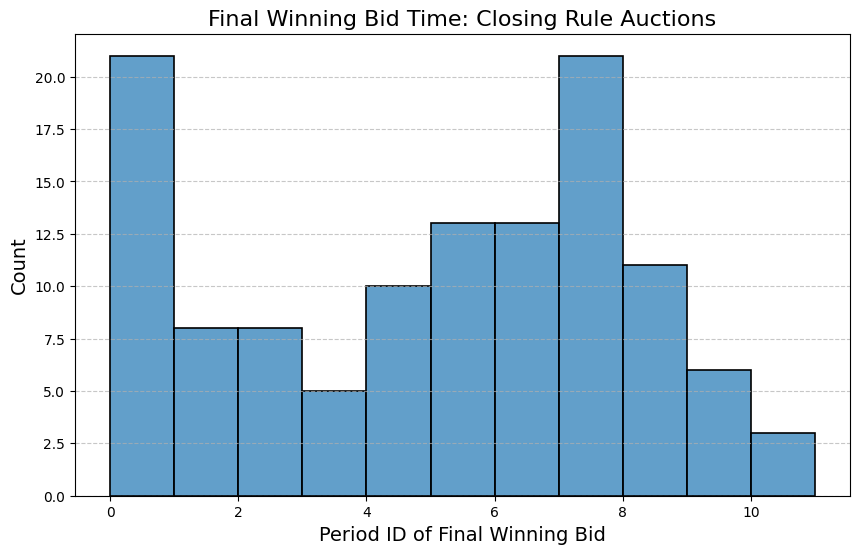

In [40]:
def plot_final_winning_bid_histograms_separate(all_dfs, closing_keys, non_closing_keys):
    """
    Plots separate histograms of the period when the final winning price was first bid,
    for closing rule auctions and non-closing rule auctions.
    
    Args:
        all_dfs (dict): Dictionary of experiment DataFrames.
        closing_keys (list): List of closing rule experiment keys.
        non_closing_keys (list): List of non-closing rule experiment keys.
    """
    closing_final_periods = []
    non_closing_final_periods = []

    for exp_name in closing_keys:
        if exp_name in all_dfs:
            df = all_dfs[exp_name].copy()
            experiment_final_periods = []
            for exp_num in df["exp_num"].unique():
                run_data = df[df["exp_num"] == exp_num].sort_values("period_id")
                final_price = run_data["current_price"].iloc[-1]
                final_period = run_data[run_data["current_price"] == final_price]["period_id"].min()
                if not np.isnan(final_period):
                    experiment_final_periods.append(final_period)
            closing_final_periods.extend(experiment_final_periods)

    for exp_name in non_closing_keys:
        if exp_name in all_dfs:
            df = all_dfs[exp_name].copy()
            experiment_final_periods = []
            for exp_num in df["exp_num"].unique():
                run_data = df[df["exp_num"] == exp_num].sort_values("period_id")
                final_price = run_data["current_price"].iloc[-1]
                final_period = run_data[run_data["current_price"] == final_price]["period_id"].min()
                if not np.isnan(final_period):
                    experiment_final_periods.append(final_period)
            non_closing_final_periods.extend(experiment_final_periods)

    # Plot non-closing rule auctions separately
    plt.figure(figsize=(10,6))
    sns.histplot(non_closing_final_periods, binwidth=1, color="#d62728", alpha=0.7, edgecolor="black", linewidth=1.2)
    plt.xlabel("Period ID of Final Winning Bid", fontsize=14)
    plt.ylabel("Count", fontsize=14)
    plt.title("Final Winning Bid Time: Non-Closing Rule Auctions", fontsize=16)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

    # Plot closing rule auctions separately
    plt.figure(figsize=(10,6))
    sns.histplot(closing_final_periods, binwidth=1, color="#1f77b4", alpha=0.7, edgecolor="black", linewidth=1.2)
    plt.xlabel("Period ID of Final Winning Bid", fontsize=14)
    plt.ylabel("Count", fontsize=14)
    plt.title("Final Winning Bid Time: Closing Rule Auctions", fontsize=16)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

plot_final_winning_bid_histograms_separate(
    all_dfs,
    closing_keys=["closing_rule", "closing_rule_hidden_40", "closing_rule_hidden_50", "closing_rule_hidden_60"],
    non_closing_keys=["basic_proxy", "hidden_reserve_40", "hidden_reserve_50", "hidden_reserve_60"]
)

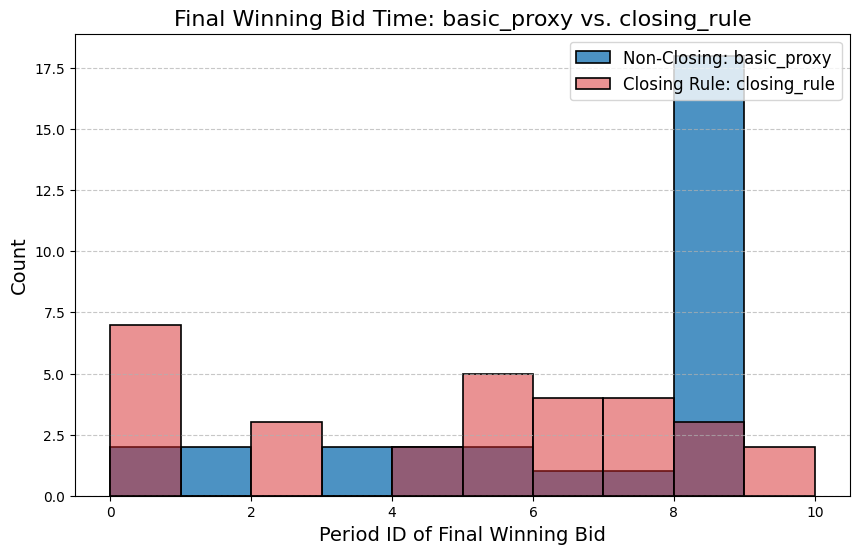

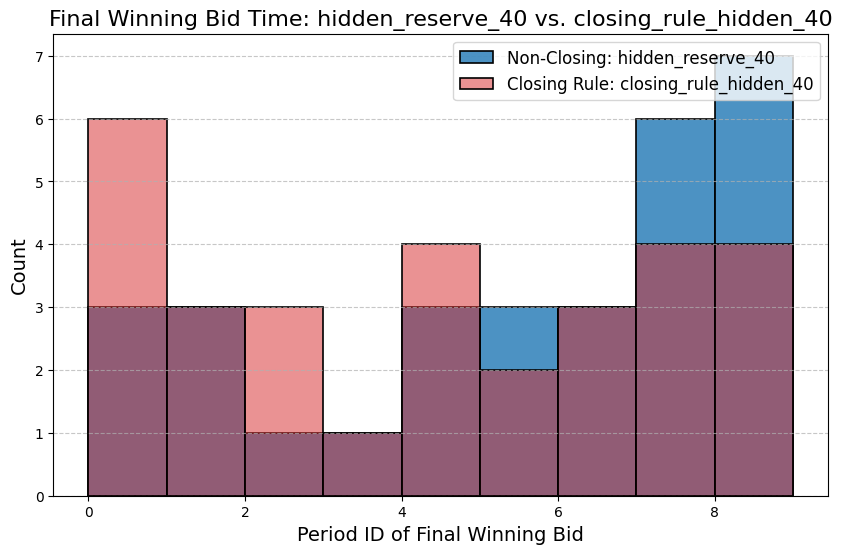

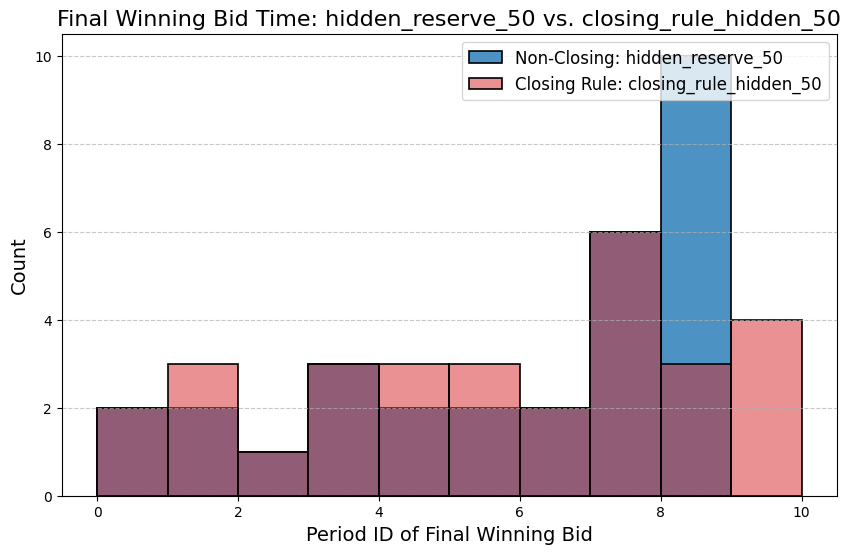

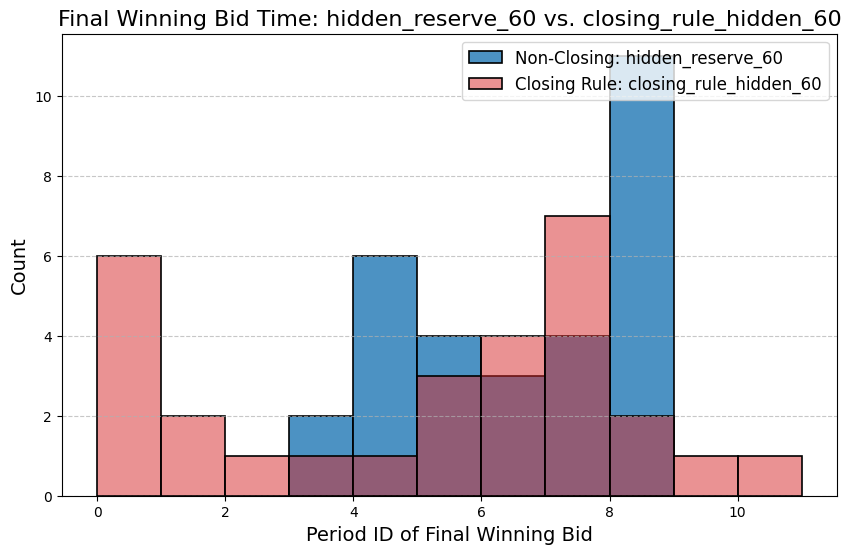

In [26]:
def plot_overlayed_final_bid_histograms(all_dfs, auction_pairs):
    """
    Plots overlaid histograms of final winning bid times for each auction vs. its closing rule counterpart.
    
    Args:
        all_dfs (dict): Dictionary of experiment DataFrames.
        auction_pairs (list of tuples): List of (non-closing, closing) auction pairs.
    """
    for non_closing, closing in auction_pairs:
        if non_closing not in all_dfs or closing not in all_dfs:
            print(f"Skipping {non_closing} vs. {closing} - missing data")
            continue
        
        non_closing_periods = []
        closing_periods = []

        # Extract periods when the final winning bid was placed
        for exp_num in all_dfs[non_closing]["exp_num"].unique():
            df = all_dfs[non_closing]
            run_data = df[df["exp_num"] == exp_num].sort_values("period_id")
            final_price = run_data["current_price"].iloc[-1]
            final_period = run_data[run_data["current_price"] == final_price]["period_id"].min()
            if not np.isnan(final_period):
                non_closing_periods.append(final_period)

        for exp_num in all_dfs[closing]["exp_num"].unique():
            df = all_dfs[closing]
            run_data = df[df["exp_num"] == exp_num].sort_values("period_id")
            final_price = run_data["current_price"].iloc[-1]
            final_period = run_data[run_data["current_price"] == final_price]["period_id"].min()
            if not np.isnan(final_period):
                closing_periods.append(final_period)

        # Plot overlayed histograms with improved aesthetics
        plt.figure(figsize=(10,6))

        sns.histplot(non_closing_periods, binwidth=1, color="#1f77b4", alpha=0.8, edgecolor="black", linewidth=1.2, label=f"Non-Closing: {non_closing}")
        sns.histplot(closing_periods, binwidth=1, color="#d62728", alpha=0.5, edgecolor="black", linewidth=1.2, label=f"Closing Rule: {closing}")

        plt.xlabel("Period ID of Final Winning Bid", fontsize=14)
        plt.ylabel("Count", fontsize=14)
        plt.title(f"Final Winning Bid Time: {non_closing} vs. {closing}", fontsize=16)
        plt.legend(fontsize=12, loc="upper right", frameon=True)

        plt.grid(axis="y", linestyle="--", alpha=0.7)  # Subtle grid lines for readability
        plt.show()


auction_pairs = [
    ("basic_proxy", "closing_rule"),
    ("hidden_reserve_40", "closing_rule_hidden_40"),
    ("hidden_reserve_50", "closing_rule_hidden_50"),
    ("hidden_reserve_60", "closing_rule_hidden_60"),
]

plot_overlayed_final_bid_histograms(all_dfs, auction_pairs)


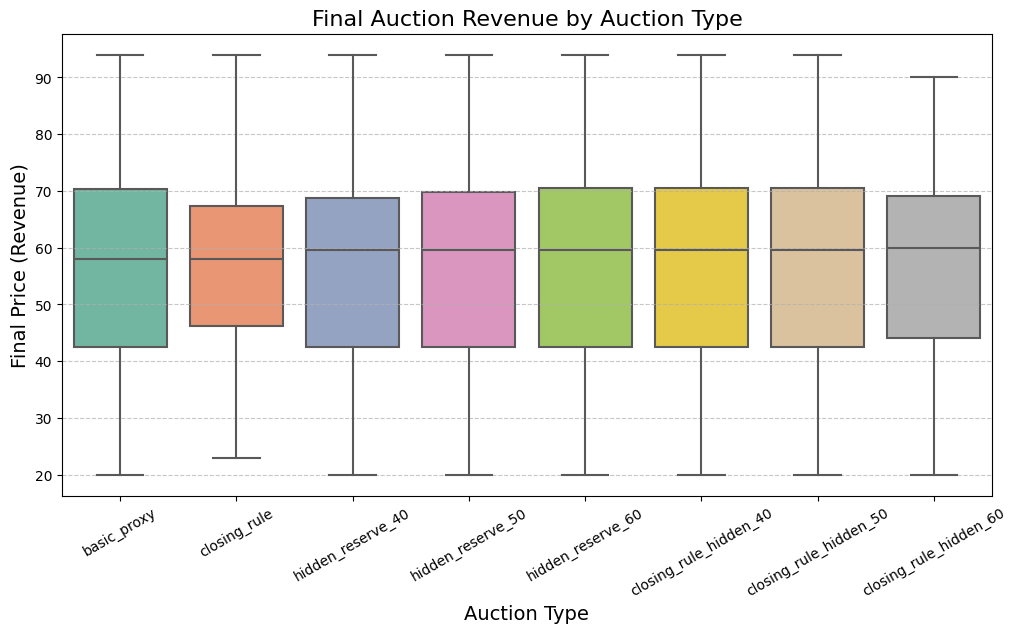

In [36]:
def plot_revenue_boxplot(all_dfs, experiment_labels):
    """
    Plots a boxplot of final revenue (final winning price) for each auction type.

    Args:
        all_dfs (dict): Dictionary of experiment DataFrames.
        experiment_labels (list): List of experiment names to include in the plot.
    """
    revenue_data = []

    for exp_name in experiment_labels:
        if exp_name in all_dfs:
            df = all_dfs[exp_name].copy()
            for exp_num in df["exp_num"].unique():
                run_data = df[df["exp_num"] == exp_num].sort_values("period_id")
                final_price = run_data["current_price"].iloc[-1]  # Final auction price
                revenue_data.append({"Experiment": exp_name, "Final Price": final_price})

    # Convert to DataFrame
    revenue_df = pd.DataFrame(revenue_data)

    # Plot boxplot
    plt.figure(figsize=(12,6))
    sns.boxplot(x="Experiment", y="Final Price", data=revenue_df, palette="Set2")
    
    plt.xlabel("Auction Type", fontsize=14)
    plt.ylabel("Final Price (Revenue)", fontsize=14)
    plt.title("Final Auction Revenue by Auction Type", fontsize=16)
    plt.xticks(rotation=30)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

plot_revenue_boxplot(
    all_dfs,
    experiment_labels=["basic_proxy", "closing_rule", "hidden_reserve_40", 
                       "hidden_reserve_50", "hidden_reserve_60", 
                       "closing_rule_hidden_40", "closing_rule_hidden_50", "closing_rule_hidden_60"]
)


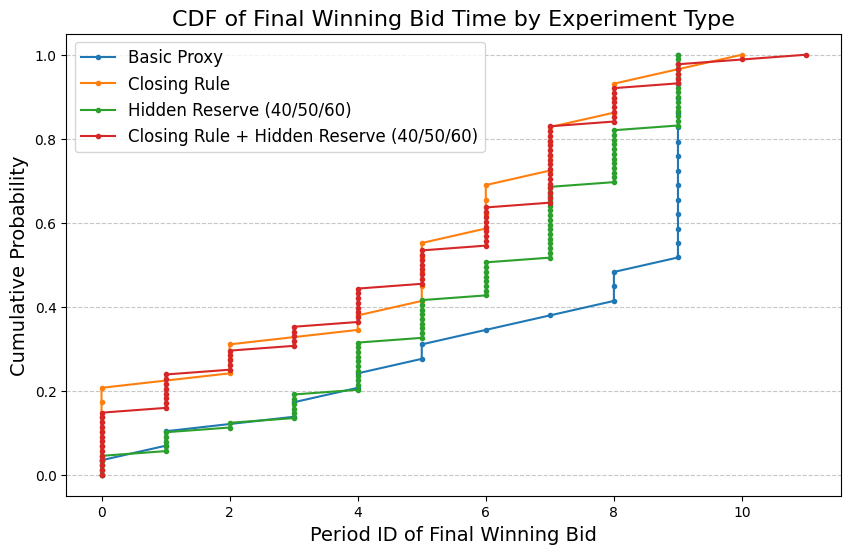

In [37]:
def aggregate_cdf_last_bid_grouped(all_dfs):
    """
    Aggregates last bid periods for each experiment type and groups:
    - Basic Proxy (single line)
    - Closing Rule (single line)
    - Hidden Reserve (40, 50, 60 combined into one line)
    - Closing Rule + Hidden Reserve (40, 50, 60 combined into one line)

    Creates a combined CDF plot.
    """
    grouped_experiments = {
        "Basic Proxy": ["basic_proxy"],
        "Closing Rule": ["closing_rule"],
        "Hidden Reserve (40/50/60)": ["hidden_reserve_40", "hidden_reserve_50", "hidden_reserve_60"],
        "Closing Rule + Hidden Reserve (40/50/60)": ["closing_rule_hidden_40", "closing_rule_hidden_50", "closing_rule_hidden_60"]
    }

    plt.figure(figsize=(10,6))

    for label, exp_list in grouped_experiments.items():
        last_bid_periods = []

        for exp_name in exp_list:
            if exp_name in all_dfs:
                df = all_dfs[exp_name]
                for exp_num in df["exp_num"].unique():
                    run_data = df[df["exp_num"] == exp_num].sort_values("period_id")
                    final_price = run_data["current_price"].iloc[-1]  # Final price
                    final_period = run_data[run_data["current_price"] == final_price]["period_id"].min()
                    if not np.isnan(final_period):
                        last_bid_periods.append(final_period)

        if last_bid_periods:
            plot_cdf_from_list(last_bid_periods, label=label)

    plt.xlabel("Period ID of Final Winning Bid", fontsize=14)
    plt.ylabel("Cumulative Probability", fontsize=14)
    plt.title("CDF of Final Winning Bid Time by Experiment Type", fontsize=16)
    plt.legend(fontsize=12, loc="upper left", frameon=True)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

aggregate_cdf_last_bid_grouped(all_dfs)


In [38]:
from scipy.stats import ttest_ind
import pandas as pd

def compute_seller_revenue(df):
    """Extracts final auction revenue (winning bid price) for each experiment run."""
    return [
        df[df["exp_num"] == exp_num]["current_price"].iloc[-1]
        for exp_num in df["exp_num"].unique()
    ]

def test_revenue_differences(all_dfs):
    """
    Runs pairwise t-tests to compare seller revenue across auction types.
    Returns results as a DataFrame.
    """
    revenue_data = {exp_name: compute_seller_revenue(df) for exp_name, df in all_dfs.items()}
    
    auction_types = list(revenue_data.keys())
    results = []

    for i in range(len(auction_types)):
        for j in range(i + 1, len(auction_types)):
            auction1 = auction_types[i]
            auction2 = auction_types[j]
            
            rev1 = revenue_data[auction1]
            rev2 = revenue_data[auction2]
            
            if rev1 and rev2:
                t_stat, p_val = ttest_ind(rev1, rev2, equal_var=False)
                results.append({
                    "Auction Type 1": auction1,
                    "Auction Type 2": auction2,
                    "t-statistic": round(t_stat, 3),
                    "p-value": format(p_val, ".3g")
                })

    return pd.DataFrame(results)

# Run the tests and store results
revenue_test_results = test_revenue_differences(all_dfs)

def generate_latex_table(df, caption="Pairwise t-tests for Seller Revenue Differences", label="tab:revenue_tests"):
    """
    Converts a DataFrame into a formatted LaTeX table.
    """
    latex_code = df.to_latex(index=False, escape=False, column_format="l l c c",
                             caption=caption, label=label, float_format="%.3f")
    
    return latex_code

# Generate the LaTeX table
latex_code = generate_latex_table(revenue_test_results)

# Print the LaTeX table
print(latex_code)


\begin{table}
\caption{Pairwise t-tests for Seller Revenue Differences}
\label{tab:revenue_tests}
\begin{tabular}{l l c c}
\toprule
Auction Type 1 & Auction Type 2 & t-statistic & p-value \\
\midrule
basic_proxy & closing_rule & 0.020 & 0.984 \\
basic_proxy & hidden_reserve_40 & -0.026 & 0.98 \\
basic_proxy & hidden_reserve_50 & -0.096 & 0.923 \\
basic_proxy & hidden_reserve_60 & -0.071 & 0.944 \\
basic_proxy & closing_rule_hidden_40 & -0.109 & 0.913 \\
basic_proxy & closing_rule_hidden_50 & -0.109 & 0.913 \\
basic_proxy & closing_rule_hidden_60 & -0.119 & 0.905 \\
closing_rule & hidden_reserve_40 & -0.047 & 0.963 \\
closing_rule & hidden_reserve_50 & -0.120 & 0.905 \\
closing_rule & hidden_reserve_60 & -0.093 & 0.926 \\
closing_rule & closing_rule_hidden_40 & -0.133 & 0.895 \\
closing_rule & closing_rule_hidden_50 & -0.133 & 0.895 \\
closing_rule & closing_rule_hidden_60 & -0.144 & 0.886 \\
hidden_reserve_40 & hidden_reserve_50 & -0.071 & 0.944 \\
hidden_reserve_40 & hidden_reserve_60